Previously, we have used normal neural networks for classifying number, now we will use a more stronger one, convolutional neural network!

Shape of data (50000, 28, 28, 1)
Shape of target (50000,)


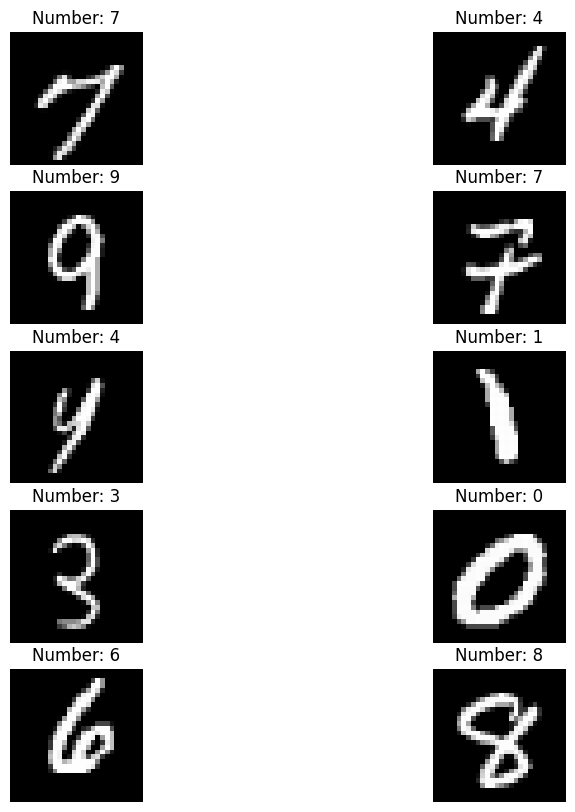

In [21]:
import numpy as np 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # type: ignore
from sklearn.model_selection import train_test_split

# Load data into variable
data = np.load("data/mnist.npz") 

# Extract train, test, file
x_train, x_test, y_train, y_test = data["x_train"], data["x_test"], data["y_train"], data["y_test"]

# Split train and validation for no bias !!!
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=10000, random_state = 194
) # 50k train, 10k validate, 10k testing !

# Change the shape of the feature to be (28,28,1) for convolutional neural networks
x_train = np.expand_dims(x_train, axis =3)
x_val = np.expand_dims(x_val, axis =3)
x_test = np.expand_dims(x_test, axis =3)

# Convert integer labels to one-hot vectors for better loss function
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_val_onehot = keras.utils.to_categorical(y_val, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)

print("Shape of data", x_train.shape)
print("Shape of target", y_train.shape)

#Draw first 10 number in train to see
plt.figure(figsize=(10,10)) #width 10, height 10
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(x_train[i], cmap="gray")  # change cmap if RGB
    plt.title(f"Number: {y_train[i]}")
    plt.axis("off")
plt.show()

Then next, we will define the layer of the model and the compile of the model. In this scenario, I have increase two more convolutional and pooling layer but reduce a dense layer.

In [22]:
# Creating my model
model = keras.Sequential([
    # first layer of extracting feature and pooling (exaggerate it) for simple feature
    layers.Conv2D(filters=16, kernel_size=(3,3), activation ="relu", padding ="same", input_shape =(28,28,1)),
    layers.MaxPooling2D((2,2)),
    # second layer for complex feature
    layers.Conv2D(filters=32, kernel_size=(3,3), activation ="relu", padding ="same"),
    layers.MaxPooling2D((2,2)),

    # expect size after that (7,7,32) ~1568 neural networks

    layers.Flatten(),   # Turn 2D into 1D

    layers.Dense(64, activation = "relu"), #taking in input,first layer
    layers.Dropout(0.6),
    layers.BatchNormalization(),

    layers.Dense(32, activation = "sigmoid" ), # fourth layer
    layers.Dropout(0.1),

    layers.Dense(10, activation = "softmax") #Result as probabilities of final results
])

#defining optimizer, in this case adam ~ gradient descent
#loss will be mean absolute error
model.compile(
    optimizer = "adam",
    loss ="mean_squared_error",
    metrics=["accuracy"]
)

d:\bao_lam\repos\Machine-Learning-Playground\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Next, we will fit the data into the model for it to training, Also to prevent it from start epoch with no stop, add EarlyStopping

In [23]:
from tensorflow.keras.callbacks import EarlyStopping # type: ignore
early_stop = EarlyStopping(
    monitor = "val_loss", 
    patience = 3, # stop if no improvement for 3 epochs
    restore_best_weights = True,  # roll back to the best model
    min_delta = 0.001,   # require at least +0.1% improvement

)



history = model.fit(
    x_train, y_train_onehot, # testing data
    validation_data =(x_val, y_val_onehot), # validation data
    batch_size = 16, # after 32 sample, the optimizer will change the weights
    epochs = 20,
    callbacks =[early_stop],
)

Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.5799 - loss: 0.0554 - val_accuracy: 0.9512 - val_loss: 0.0096
Epoch 2/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 57s 14ms/step - accuracy: 0.7616 - loss: 0.0339 - val_accuracy: 0.9541 - val_loss: 0.0072
Epoch 3/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - accuracy: 0.8081 - loss: 0.0280 - val_accuracy: 0.9484 - val_loss: 0.0079
Epoch 4/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.8249 - loss: 0.0256 - val_accuracy: 0.9500 - val_loss: 0.0076
Epoch 5/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8306 - loss: 0.0248 - val_accuracy: 0.9659 - val_loss: 0.0051
Epoch 6/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8615 - loss: 0.0206 - val_accuracy: 0.9721 - val_loss: 0.0042
Epoch 7/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8710 - loss: 0.0194 - val_accuracy: 0.9773 - val_loss: 0.0035
Epoch 8/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.8823 - loss:

A better way to view the loss though is to plot it. The fit method in fact keeps a record of the loss produced during training in a History object. We'll convert the data to a Pandas dataframe, which makes the plotting easy.

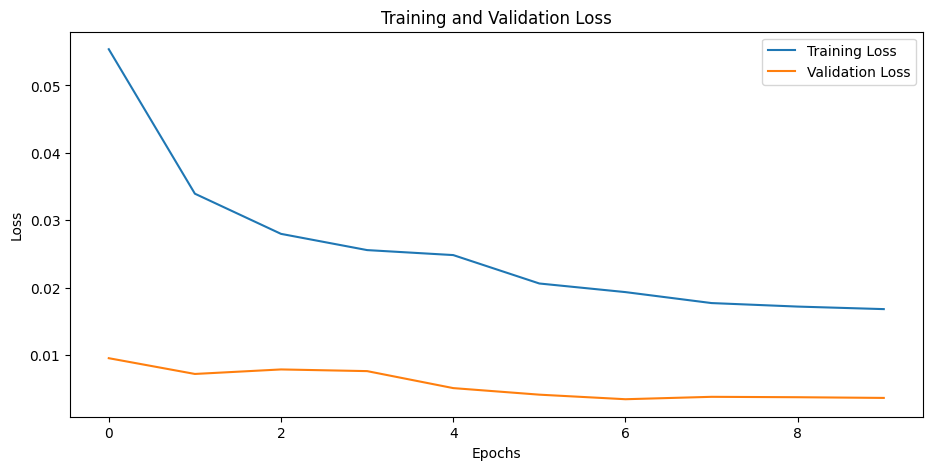

In [25]:
import pandas as pd
# convert the training history to a dataframe
plt.figure(figsize =(11,5))
history_df = pd.DataFrame(history.history)
# use Pandas native plot method
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Checking the accuracy of the model on test data:

In [26]:
loss, accuracy = model.evaluate(x_test, y_test_onehot, verbose=1)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9782 - loss: 0.0032
Test Loss: 0.0032
Test Accuracy: 0.9782


After training, we have initial training weight already, but to stop from start again over and over again, we save the model totally into a new file and use it again for production.

In [ ]:
model.save("final_model/CNNmodelver1.keras")
model.save("final_model/CNNmodelver1.h5") 

Conclusion : the CNN model is better at recognizing the 2D pattern and has better accuracy compared to the DNN model